In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(color_codes=True)
#Deta normilzation usign Min-Max scale
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
#Data Training
from sklearn.model_selection import train_test_split
#K-Nearest Neighbors
from sklearn.neighbors import  KNeighborsClassifier 
#Random Forest
from sklearn.ensemble import RandomForestClassifier
#K means clustering 
from sklearn.cluster import KMeans
#Generating in 
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
#Mean
from sklearn.impute import SimpleImputer
#Accurarcy
from sklearn.metrics import accuracy_score
#f1 score
from sklearn.metrics import classification_report
import time


In [2]:
#Data Cleaning

In [3]:
df= pd.read_csv("gene_1.csv")
#Shows the first f columns in table
df.head(5)

,Accession,Title,Source name,Tissue,Sample_id,Sex,Age at death,Diagnosis,Braak score,Rin_score,Post_mortem_interval,Caseid
0,GSM2516806,SAM19655462 F 97 AD V,RNA from fusiform gyrus,fusiform gyrus,SAM19655462,1,97,Alzheimer's disease,5,6.9,3.16,May-57
1,GSM2516807,SAM19655402 F 97 AD IV,RNA from fusiform gyrus,fusiform gyrus,SAM19655402,1,97,Alzheimer's disease,4,7.1,3.33,Oct-43
2,GSM2516808,SAM19655463 F 87 AD V,RNA from fusiform gyrus,fusiform gyrus,SAM19655463,1,87,Alzheimer's disease,5,6.1,3.00,2-Jul
3,GSM2516809,SAM19655497 M 82 CON III,RNA from fusiform gyrus,fusiform gyrus,SAM19655497,0,82,control,3,6.8,3.00,16-May
4,GSM2516810,SAM19655435 M 80 AD V,RNA from fusiform gyrus,fusiform gyrus,SAM19655435,0,80,Alzheimer's disease,5,5.5,2.50,18-Sep


In [4]:
#Shows the attriibutes
df.dtypes

Accession                object
Title                    object
Source name              object
Tissue                   object
Sample_id                object
Sex                       int64
Age at death              int64
Diagnosis                object
Braak score               int64
Rin_score               float64
Post_mortem_interval    float64
Caseid                   object
dtype: object

In [5]:
#Checkign for duplicated rows
duplicated_rows_df = df[df.duplicated()]
print("Number of duplicated rows:", duplicated_rows_df)
#Dropping any duplicated rows
df = df.drop_duplicates()
df.head(5);

Number of duplicated rows: Empty DataFrame
Columns: [Accession, Title, Source name, Tissue, Sample_id, Sex, Age at death, Diagnosis, Braak score, Rin_score, Post_mortem_interval, Caseid]
Index: []


In [6]:
#Checks number of columns and rows
df.shape

(117, 12)

In [7]:
print(df.isnull().sum())

Accession               0
Title                   0
Source name             0
Tissue                  0
Sample_id               0
Sex                     0
Age at death            0
Diagnosis               0
Braak score             0
Rin_score               0
Post_mortem_interval    0
Caseid                  0
dtype: int64


In [8]:
#Dropped attirbutes that ar Unnessary
columns_dropped = ['Accession', 'Title', 'Source name', 'Caseid']
df=df.drop(columns= columns_dropped, axis=1)
#Shows the first five columns with the dropped attributes
df.head(5)

,Tissue,Sample_id,Sex,Age at death,Diagnosis,Braak score,Rin_score,Post_mortem_interval
0,fusiform gyrus,SAM19655462,1,97,Alzheimer's disease,5,6.9,3.16
1,fusiform gyrus,SAM19655402,1,97,Alzheimer's disease,4,7.1,3.33
2,fusiform gyrus,SAM19655463,1,87,Alzheimer's disease,5,6.1,3.00
3,fusiform gyrus,SAM19655497,0,82,control,3,6.8,3.00
4,fusiform gyrus,SAM19655435,0,80,Alzheimer's disease,5,5.5,2.50


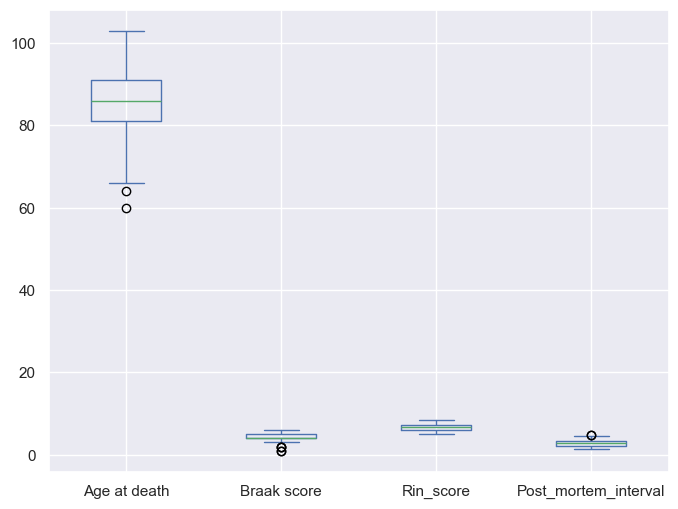

In [9]:
#box plot input the attrbutes you want to show as attributes
Attributes = ['Age at death', 'Braak score', 'Rin_score', 'Post_mortem_interval']
df[Attributes].plot(kind='box', figsize=(8,6))
#Shows the attributes
plt.show()

In [10]:
#filling missign values with mean
# Attributes = []
imputer = SimpleImputer(strategy='mean')
df[Attributes] = imputer.fit_transform(df[Attributes])

In [11]:
#Normilaztion
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df[Attributes])
df_scaled = pd.DataFrame(df_scaled, columns=Attributes)

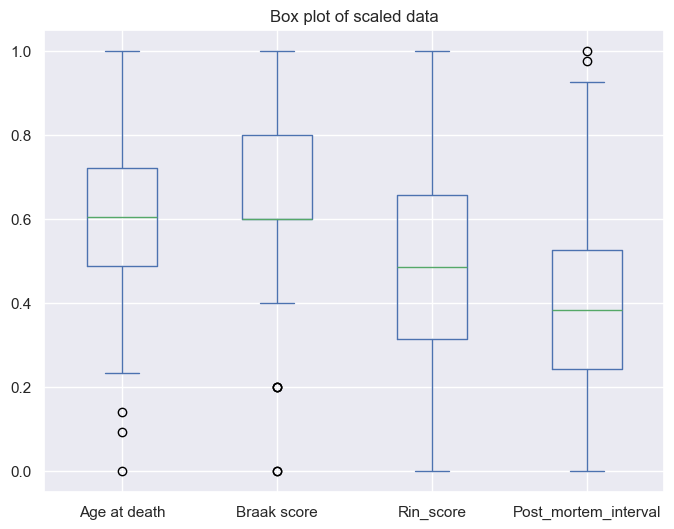

In [12]:
#Box plot after scaling
#redue the box plot for the attributes to make sure all of them have been sclaed properly between 0-1
#box plot input the attrbutes you want to show as attributes
df_scaled.plot(kind='box', figsize=(8,6))
plt.title("Box plot of scaled data")
plt.show()

In [13]:
# Creating a manual dataset
# pd.read_csv("")
# df = pd.read_csv("")
# data = df.sample(n=).copy()

C:\Users\tkiya\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


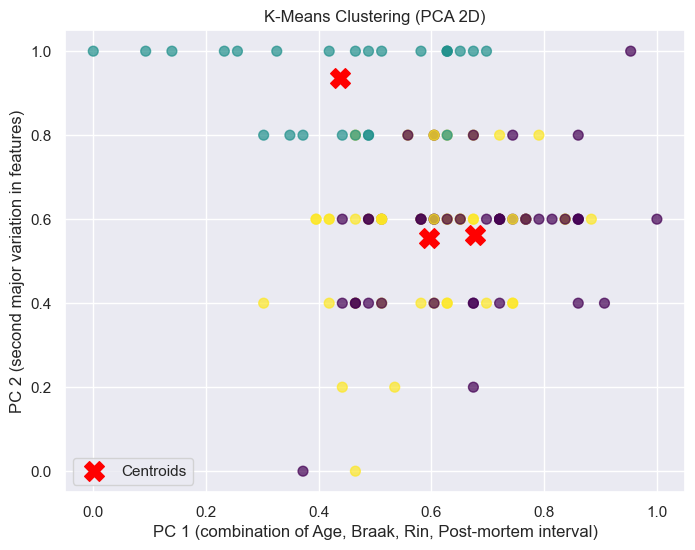

In [14]:
#K means implementation

#scaling the features
X = df_scaled.values
#k means
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
# labeling each cluster
labels = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_

#reduc the 2d of hte plotting
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)
centroids_2d = pca.transform(centroids)
#This makes the scatter plot clusters
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')
#labeling
plt.xlabel('PC 1 (combination of Age, Braak, Rin, Post-mortem interval)')
plt.ylabel('PC 2 (second major variation in features)')
plt.title('K-Means Clustering (PCA 2D)')
plt.legend()
plt.grid(True)
plt.show()

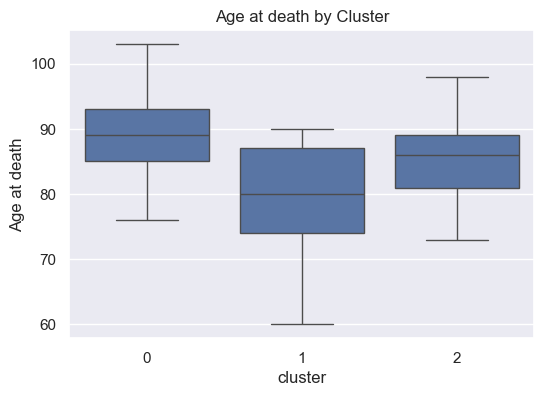

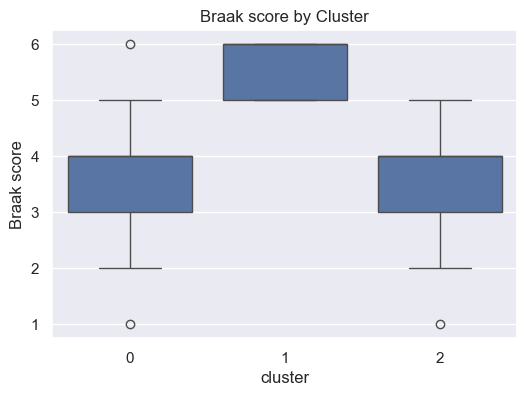

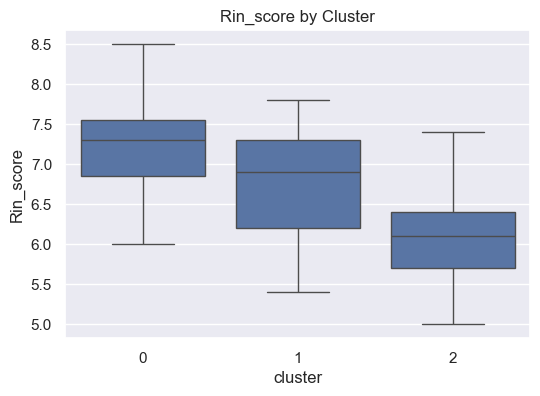

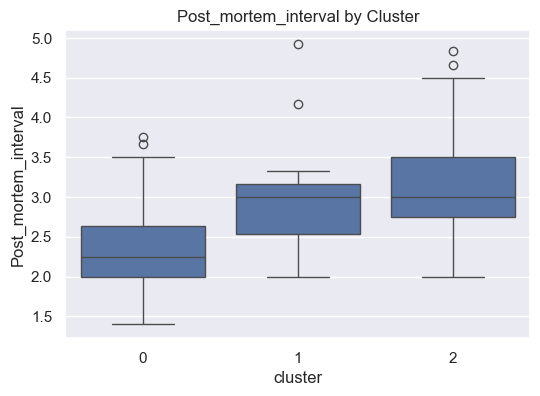

In [15]:
#shows k means clustering in number
numerical_cols = ['Age at death', 'Braak score', 'Rin_score', 'Post_mortem_interval']
df['cluster'] = labels
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='cluster', y=col, data=df)
    plt.title(f'{col} by Cluster')
    plt.show()

In [16]:
#Dropped attirbutes that after doing k-meand and seeing what are needed
#df=df.drop([''])
#Shows the first five columns with the dropped attributes
#df.head(5)

In [17]:
df.dropna(subset=['Braak score'], inplace=True)

In [18]:
#Training the data
#Splitting into 80% to 20% triaing
x= df[Attributes]
y= df['Braak score']
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, random_state=42
)
print("x_train:", x_train.shape)
print("x_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

x_train: (93, 4)
x_test: (24, 4)
y_train: (93,)
y_test: (24,)


In [19]:
#KNN classifer Implentation

In [20]:
#KNN classifer Implentation
# Have to figure out the best K paramters 
# All the attributes used for the classfier to preedict BRAAKING stage
x = df[['Age at death', 'Rin_score', 'Post_mortem_interval']]

# The predictied variable
y = df['Braak score']

# Train/test split 20% to 80%
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# Scaling/normilizting the data
scaler_knn = StandardScaler()
x_train_scaled = scaler_knn.fit_transform(x_train)
x_test_scaled = scaler_knn.transform(x_test)

# KNN model PREDICTIONS
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train_scaled, y_train)
y_pred_knn = knn.predict(x_test_scaled)

# Metrics
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


#result show this isnt enough for it to work the accurarcy is low

KNN Accuracy: 0.375
              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00         1
         2.0       0.00      0.00      0.00         0
         3.0       0.00      0.00      0.00         4
         4.0       0.73      0.67      0.70        12
         5.0       0.00      0.00      0.00         2
         6.0       0.50      0.20      0.29         5

    accuracy                           0.38        24
   macro avg       0.20      0.14      0.16        24
weighted avg       0.47      0.38      0.41        24



C:\Users\tkiya\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\tkiya\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\tkiya\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\tkiya\anaconda3\Lib\site-pa

In [21]:
#Checking the attrubte names
df.columns

Index(['Tissue', 'Sample_id', 'Sex', 'Age at death', 'Diagnosis',
       'Braak score', 'Rin_score', 'Post_mortem_interval', 'cluster'],
      dtype='object')

In [22]:
#This makes sure that the all attribute are included 
df_encoded = pd.get_dummies(df, columns=['Sex', 'Diagnosis', 'Tissue'], drop_first=True)
#removes and boolean vrables
df_encoded = df_encoded.apply(lambda col: col.astype(int) if col.dtype == bool else col)
#drops sample id as it messed with the prediction
df_encoded = df_encoded.drop(columns=['Sample_id'])

x = df_encoded.drop(columns=['Braak score'])
y = df_encoded['Braak score']
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [23]:

#Trying KNN again with all the attrbutes
#turing all the catefories into numbers
# df_encoded = pd.get_dummies(df, columns=['Sex', 'Diagnosis', 'Tissue'], drop_first=True)

# # Remove all non-numeric columns
# #df_encoded = df_encoded.select_dtypes(include=['number'])
# x = df_encoded.drop(columns=['Braak score'])
# y = df_encoded['Braak score']

# # Train/test split
# x_train, x_test, y_train, y_test = train_test_split(
#     x, y, test_size=0.2, random_state=42
# )

# Scaling the data
scaler_knn = StandardScaler()
x_train_scaled = scaler_knn.fit_transform(x_train)
x_test_scaled = scaler_knn.transform(x_test)

# KNN implementation
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train_scaled, y_train)
y_pred_knn = knn.predict(x_test_scaled)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


#Result improved accurarcy with more data however since its tested on 20 percnt whcih is low reslut arent that great
#predicted braak stage 4 and 6 the best 

KNN Accuracy: 0.375
              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00         1
         3.0       0.40      0.50      0.44         4
         4.0       0.40      0.33      0.36        12
         5.0       0.00      0.00      0.00         2
         6.0       1.00      0.60      0.75         5

    accuracy                           0.38        24
   macro avg       0.36      0.29      0.31        24
weighted avg       0.48      0.38      0.41        24



C:\Users\tkiya\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\tkiya\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\tkiya\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [24]:
#Random Forst implemntation

In [25]:
#makes 300 treese to comapre
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)
#train
rf.fit(x_train, y_train)
#predcit
y_pred_rf = rf.predict(x_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.4583333333333333
              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00         1
         3.0       0.25      0.25      0.25         4
         4.0       0.55      0.50      0.52        12
         5.0       0.00      0.00      0.00         2
         6.0       1.00      0.80      0.89         5

    accuracy                           0.46        24
   macro avg       0.36      0.31      0.33        24
weighted avg       0.52      0.46      0.49        24



C:\Users\tkiya\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\tkiya\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\tkiya\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [26]:
#This checks each attributes significance to the random forest predictor
features_list = X_new.columns
importances = rf.feature_importances_

print("\nFeature Importance Rankings:")
for f, i in sorted(zip(features_list, importances), key=lambda x: x[1], reverse=True):
    print(f"{f}: {i:.4f}")

plt.figure(figsize=(10, 6))
plt.barh(features_list, importances)
plt.xlabel("Importance")
plt.title("Random Forest Feature Importances")
plt.gca().invert_yaxis()
plt.show()

NameError: name 'X_new' is not defined

In [ ]:
#Random Forest implentation pt 2

In [ ]:

#Random forest again but with less attrbutes
#only trainign with these attributes
df_encoded = pd.get_dummies(df, columns=['Sex', 'Diagnosis', 'Tissue'], drop_first=True)
#remvoces the number attrubte as it messes with the code
df_encoded = df_encoded.select_dtypes(include=['number'])

x = df_encoded.drop(columns=['Braak score'])
y = df_encoded['Braak score']
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)
#train
rf.fit(x_train, y_train)
#test
y_rf_pred = rf.predict(x_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_rf_pred))
print(classification_report(y_test, y_rf_pred, zero_division=0))

df_encoded.head()


In [ ]:
#Random Forest implentation
df_encoded = pd.get_dummies(df, columns=['Sex', 'Diagnosis', 'Tissue'], drop_first=True)

# Turn all attrvutes itno numebrs
X_new = df[['Age at death', 'Rin_score', 'Post_mortem_interval']]
y_new = df['Braak score']


# Train/test split data
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42
)
# Random Forest model implementation
#300 tells how man trees to maket o comapre
# the balanced/weight helps balace out the data
rf_new = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)


# Training the data
rf_new.fit(X_train_new, y_train_new)
y_pred_rf_new = rf_new.predict(X_test_new)

print("Random Forest (new) Accuracy:", accuracy_score(y_test_new, y_pred_rf_new))
print(classification_report(y_test_new, y_pred_rf_new))
#Results performed better then knn with a higher accurarcy score
# predicted braakign stage 4 and 6 the best because of the amount of smapels there where of the two if you notice they have the highest amount int eh chart

## Update Using  Bidirectional hill-climbing search for test-size optimization to improve accurarcy

In [ ]:
# KNN Classifier
# Find the best test_size for KNN

x = df[['Age at death', 'Rin_score', 'Post_mortem_interval']]
y = df['Braak score']

test_size = 0.50
step = 0.25

best_score = -float("inf")
best_test_size = None

for i in range(6):

    # -------------------------
    # Test current split
    # -------------------------
    x_train, x_test, y_train, y_test = train_test_split(
        x, y,
        test_size=test_size,
        random_state=42
    )

    # Scale data
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)

    # KNN
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(x_train_scaled, y_train)

    y_pred = knn.predict(x_test_scaled)

    score = accuracy_score(y_test, y_pred)

    print(f"Test size: {test_size:.3f} | Accuracy: {score:.3f}")

    # Keep track of best result
    if score > best_score:
        best_score = score
        best_test_size = test_size

    # -------------------------
    # Calculate upper/lower
    # -------------------------
    upper_size = min(test_size + step, 0.90)
    lower_size = max(test_size - step, 0.10)

    # Test upper split
    x_train_u, x_test_u, y_train_u, y_test_u = train_test_split(
        x, y,
        test_size=upper_size,
        random_state=42
    )

    scaler_u = StandardScaler()
    x_train_u_scaled = scaler_u.fit_transform(x_train_u)
    x_test_u_scaled = scaler_u.transform(x_test_u)

    knn_u = KNeighborsClassifier(n_neighbors=5)
    knn_u.fit(x_train_u_scaled, y_train_u)

    y_pred_u = knn_u.predict(x_test_u_scaled)

    upper_score = accuracy_score(y_test_u, y_pred_u)

    # Test lower split
    x_train_l, x_test_l, y_train_l, y_test_l = train_test_split(
        x, y,
        test_size=lower_size,
        random_state=42
    )

    scaler_l = StandardScaler()
    x_train_l_scaled = scaler_l.fit_transform(x_train_l)
    x_test_l_scaled = scaler_l.transform(x_test_l)

    knn_l = KNeighborsClassifier(n_neighbors=5)
    knn_l.fit(x_train_l_scaled, y_train_l)

    y_pred_l = knn_l.predict(x_test_l_scaled)

    lower_score = accuracy_score(y_test_l, y_pred_l)

    # -------------------------
    # Choose better direction
    # -------------------------
    if upper_score > lower_score:
        test_size = upper_size
    else:
        test_size = lower_size

    # Reduce step size
    step /= 2


print("\nBest Result")
print(f"Best test size: {best_test_size:.3f}")
print(f"Best Accuracy: {best_score:.3f}")

In [ ]:
# Random Forest
# Find the best test_size

X_new = df[['Age at death', 'Rin_score', 'Post_mortem_interval']]
y_new = df['Braak score']

test_size = 0.50
step = 0.25

best_score = -float("inf")
best_test_size = None

for i in range(6):

    # -------------------------
    # Test current split
    # -------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X_new,
        y_new,
        test_size=test_size,
        random_state=42
    )

    # Random Forest
    rf = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced'
    )

    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)

    score = accuracy_score(y_test, y_pred)

    print(f"Test size: {test_size:.3f} | Accuracy: {score:.3f}")

    # Keep track of best result
    if score > best_score:
        best_score = score
        best_test_size = test_size

    # -------------------------
    # Calculate upper/lower
    # -------------------------
    upper_size = min(test_size + step, 0.90)
    lower_size = max(test_size - step, 0.10)

    # -------------------------
    # Test upper split
    # -------------------------
    X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
        X_new,
        y_new,
        test_size=upper_size,
        random_state=42
    )

    rf_u = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced'
    )

    rf_u.fit(X_train_u, y_train_u)

    y_pred_u = rf_u.predict(X_test_u)

    upper_score = accuracy_score(y_test_u, y_pred_u)

    # -------------------------
    # Test lower split
    # -------------------------
    X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
        X_new,
        y_new,
        test_size=lower_size,
        random_state=42
    )

    rf_l = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced'
    )

    rf_l.fit(X_train_l, y_train_l)

    y_pred_l = rf_l.predict(X_test_l)

    lower_score = accuracy_score(y_test_l, y_pred_l)

    # -------------------------
    # Choose better direction
    # -------------------------
    if upper_score > lower_score:
        test_size = upper_size
    else:
        test_size = lower_size

    # Reduce step size
    step /= 2


print("\nBest Result")
print(f"Best test size: {best_test_size:.3f}")
print(f"Best Accuracy: {best_score:.3f}")

In [ ]:
# K-Means Hill Climbing
# Find the best number of clusters (K)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = df_scaled.values

k = 3
step = 1

best_score = -float("inf")
best_k = None

for i in range(6):

    # -------------------------
    # Test current K
    # -------------------------
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X)

    score = silhouette_score(X, labels)

    print(f"K: {k} | Silhouette Score: {score:.3f}")

    # Keep track of best result
    if score > best_score:
        best_score = score
        best_k = k

    # -------------------------
    # Test K above
    # -------------------------
    upper_k = k + step

    kmeans_u = KMeans(
        n_clusters=upper_k,
        random_state=42,
        n_init=10
    )

    labels_u = kmeans_u.fit_predict(X)

    upper_score = silhouette_score(X, labels_u)

    # -------------------------
    # Test K below
    # -------------------------
    lower_k = max(k - step, 2)

    kmeans_l = KMeans(
        n_clusters=lower_k,
        random_state=42,
        n_init=10
    )

    labels_l = kmeans_l.fit_predict(X)

    lower_score = silhouette_score(X, labels_l)

    # -------------------------
    # Choose better direction
    # -------------------------
    if upper_score > lower_score:
        k = upper_k
    else:
        k = lower_k


print("\nBest Result")
print(f"Best K: {best_k}")
print(f"Best Silhouette Score: {best_score:.3f}")